# Fish Classification Dataset
***
The program below shows a Convolutional Neural Network (CNN) that used the __[Fish Classification Dataset](https://www.kaggle.com/datasets/jiscecseaiml/fish-classification-dataset)__ to determine whether the **eyes or gills of the Labeo Rohita (Rohu) Fish is fresh or not**.


### Import Libraries
Import necessary libraries and dependencies

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random

#### Data Preprocessing
Collect the training and testing data from their respective directories in a dataframe and augment it to balance the number of images for each. Afterwards, create the train and test data generator.

In [3]:
# Paths
train_dir = "fish-classification-dataset/Training"
test_dir = "fish-classification-dataset/Testing"

In [4]:
# --- Function to collect file paths and labels ---
def collect_image_data(directory_path):
    filepaths = []
    labels = []
    if not os.path.isdir(directory_path):
        return pd.DataFrame() # Return empty if directory doesn't exist

    for class_name in os.listdir(directory_path):
        class_path = os.path.join(directory_path, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    filepaths.append(os.path.join(class_path, img_name))
                    labels.append(class_name)
    return pd.DataFrame({'filepath': filepaths, 'label': labels})

# --- Function to balance DataFrame by oversampling minority classes ---
def balance_dataframe(df):
    if df.empty:
        return df

    print("\nOriginal class distribution:")
    print(df['label'].value_counts())

    max_count = df['label'].value_counts().max()
    print(f"Target number of images per class (based on majority class): {max_count}")

    balanced_df = pd.DataFrame()
    for class_name in df['label'].unique():
        class_df = df[df['label'] == class_name]
        class_df_oversampled = class_df.sample(max_count, replace=True, random_state=42)
        balanced_df = pd.concat([balanced_df, class_df_oversampled])

    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
    print("\nBalanced class distribution:")
    print(balanced_df['label'].value_counts())
    return balanced_df

In [29]:
# Define constants
batch_size = 32
epochs = 10
image_height = 128
image_width = 128

# Collect and balance training data
print("\n--- Processing Training Data ---")
train_raw = collect_image_data(train_dir)
train_df = balance_dataframe(train_raw)

# Collect and balance testing data
print("\n--- Processing Testing Data ---")
test_raw_df = collect_image_data(test_dir)
test_df = balance_dataframe(test_raw_df)

# Create data generators
train_data_generator = ImageDataGenerator(
    rescale=1./255,
)
test_data_generator = ImageDataGenerator(rescale=1./255)

train_generator = train_data_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    seed=42
)

test_generator = test_data_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


--- Processing Training Data ---

Original class distribution:
label
Nonfresh_Gills    1265
Nonfresh_Eyes     1028
Fresh_Gills        613
Fresh_Eyes         233
Name: count, dtype: int64
Target number of images per class (based on majority class): 1265

Balanced class distribution:
label
Nonfresh_Eyes     1265
Nonfresh_Gills    1265
Fresh_Eyes        1265
Fresh_Gills       1265
Name: count, dtype: int64

--- Processing Testing Data ---

Original class distribution:
label
Nonfresh_Gills    316
Nonfresh_Eyes     257
Fresh_Eyes        134
Fresh_Gills        80
Name: count, dtype: int64
Target number of images per class (based on majority class): 316

Balanced class distribution:
label
Nonfresh_Gills    316
Nonfresh_Eyes     316
Fresh_Gills       316
Fresh_Eyes        316
Name: count, dtype: int64
Found 5060 validated image filenames belonging to 4 classes.
Found 1264 validated image filenames belonging to 4 classes.


In [30]:
train_generator.class_indices, test_generator.class_indices

({'Fresh_Eyes': 0, 'Fresh_Gills': 1, 'Nonfresh_Eyes': 2, 'Nonfresh_Gills': 3},
 {'Fresh_Eyes': 0, 'Fresh_Gills': 1, 'Nonfresh_Eyes': 2, 'Nonfresh_Gills': 3})

### Model Training
Create and fit the sequential model

In [40]:
tf.random.set_seed(42)

# Create model
model = Sequential([
    Input(shape=(image_height, image_width, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(train_generator.class_indices), activation='softmax')
])

# Compile the model
model.compile(loss='categorical_crossentropy', 
              optimizer=Adam(learning_rate=0.001), 
              metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

# Train the model
history = model.fit(
    train_generator,
    # steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=test_generator,
    # validation_steps=test_generator.samples // batch_size,
    callbacks=[early_stopping]
)

Epoch 1/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 700s 4s/step - accuracy: 0.6972 - loss: 0.9320 - val_accuracy: 0.9684 - val_loss: 0.0654
Epoch 2/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 658s 4s/step - accuracy: 0.9927 - loss: 0.0204 - val_accuracy: 0.9960 - val_loss: 0.0150
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 735s 5s/step - accuracy: 0.9987 - loss: 0.0075 - val_accuracy: 0.9984 - val_loss: 0.0088
Epoch 4/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 828s 5s/step - accuracy: 0.9940 - loss: 0.0197 - val_accuracy: 0.9976 - val_loss: 0.0049
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 705s 4s/step - accuracy: 0.9996 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 6/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 651s 4s/step - accuracy: 1.0000 - loss: 1.8382e-04 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 7/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 783s 5s/step - accuracy: 1.0000 - loss: 1.0276e-04 - val_accuracy: 1.0000 - val_loss: 7.6929e-04
Epoch 8/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 725s 4s/step - accuracy: 1.0000 - loss: 0.001

In [43]:
model.save('fish_model.keras')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,551,182 (74.58 MB)

 Trainable params: 6,517,060 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,034,122 (49.72 MB)

#### Model Evaluation
Plot model training curves and metrics and observe its performance. 

In [44]:
model.evaluate(test_generator)

40/40 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.9964 - loss: 0.0119


[0.020588548853993416, 0.9920886158943176]

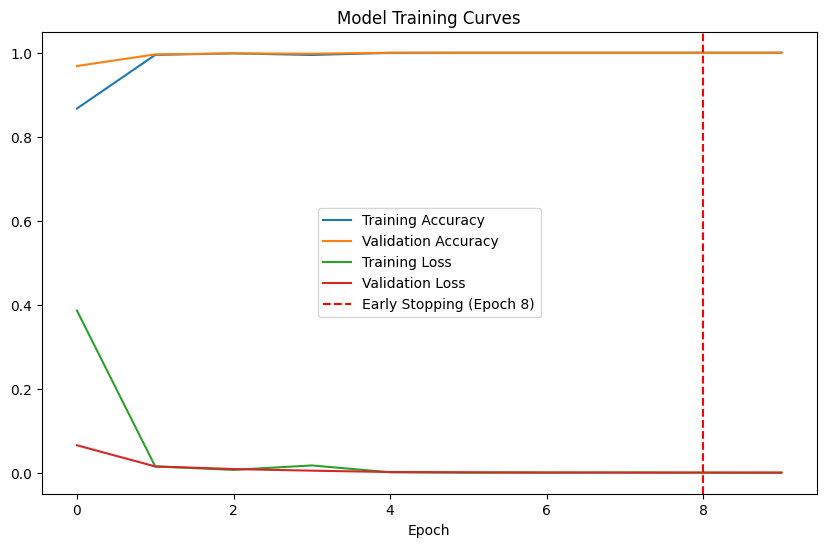

In [45]:
# Visualize training history
best_epoch_idx = np.argmin(history.history['val_loss'])

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axvline(x=(best_epoch_idx + 1), color='r', linestyle='--', label=f'Early Stopping (Epoch {best_epoch_idx + 1})')
plt.xlabel('Epoch')
plt.title('Model Training Curves')
plt.legend()
plt.show()

40/40 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step


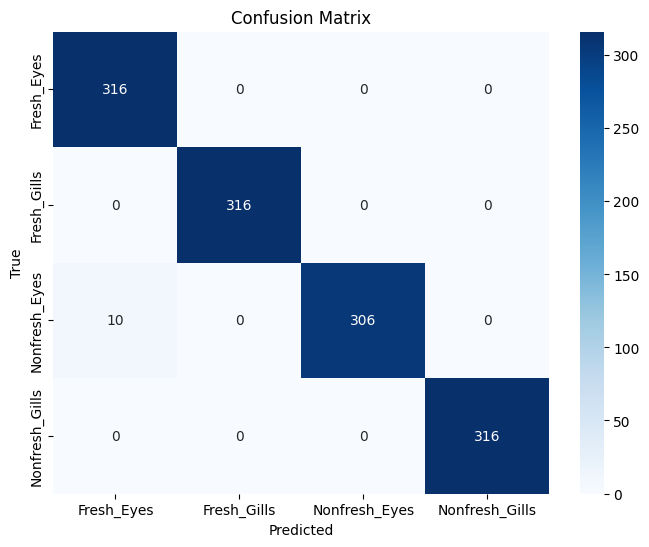

In [46]:
# Get true labels and predictions
test_generator.reset()
y_true = test_generator.classes
y_pred_prob = model.predict(test_generator, steps=test_generator.samples // batch_size + 1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = list(test_generator.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

                precision    recall  f1-score   support

    Fresh_Eyes       0.97      1.00      0.98       316
   Fresh_Gills       1.00      1.00      1.00       316
 Nonfresh_Eyes       1.00      0.97      0.98       316
Nonfresh_Gills       1.00      1.00      1.00       316

      accuracy                           0.99      1264
     macro avg       0.99      0.99      0.99      1264
  weighted avg       0.99      0.99      0.99      1264



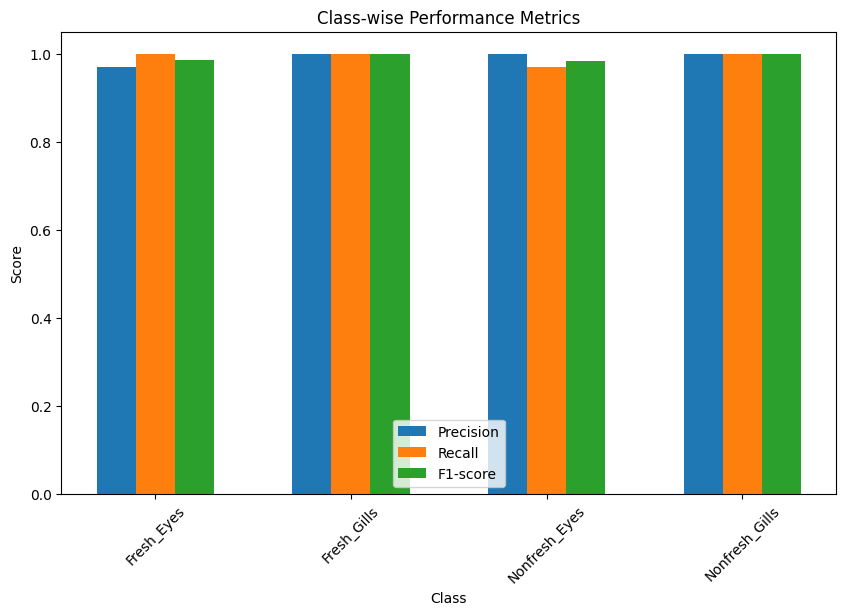

In [47]:
# Classification report
print(classification_report(y_true, y_pred, target_names=class_labels))

# Precision, Recall, F1-Score
precision, recall, fscore, _ = precision_recall_fscore_support(y_true, y_pred)

x = np.arange(len(class_labels))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, fscore, width, label='F1-score')
plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Class-wise Performance Metrics')
plt.xticks(x, class_labels, rotation=45)
plt.legend()
plt.show()

### Sample Predictions
Predict 5 images taken from test set and observe the model's performance. 

In [48]:
def predict_random_images(generator, model, class_labels, num_images=4):
    all_images = []
    all_labels = []

    generator.reset()
    for i in range(len(generator)):
        images_batch, labels_batch = generator[i]
        all_images.extend(images_batch)
        all_labels.extend(labels_batch)

    if not all_images:
        print("No images found in the generator.")
        return

    # Select `num_images` random indices
    if len(all_images) < num_images:
        print(f"Not enough images to pick {num_images}. Picking {len(all_images)} images.")
        random_indices = random.sample(range(len(all_images)), len(all_images))
    else:
        random_indices = random.sample(range(len(all_images)), num_images)

    selected_images = [all_images[i] for i in random_indices]
    selected_true_labels_one_hot = [all_labels[i] for i in random_indices]

    # Convert list of images to a single NumPy array for prediction
    input_images_batch = np.array(selected_images)

    # Make predictions for the batch
    predictions = model.predict(input_images_batch)

    plt.figure(figsize=(15, 5)) # Adjust figure size for 4 images
    for i, (sample_image, true_label_one_hot, prediction) in enumerate(zip(selected_images, selected_true_labels_one_hot, predictions)):
        plt.subplot(1, num_images, i + 1) # Arrange plots in a row

        true_label_index = np.argmax(true_label_one_hot)
        true_label_name = class_labels[true_label_index]

        predicted_class_index = np.argmax(prediction)
        predicted_class_name = class_labels[predicted_class_index]

        plt.imshow(sample_image)
        plt.title(f"True: {true_label_name}\nPred: {predicted_class_name}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nPredictions for selected random images:")
    for i in range(num_images):
        true_label_index = np.argmax(selected_true_labels_one_hot[i])
        true_label_name = class_labels[true_label_index]
        predicted_class_index = np.argmax(predictions[i])
        predicted_class_name = class_labels[predicted_class_index]
        print(f"Image {i+1}: True Label: {true_label_name}, Predicted Label: {predicted_class_name}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


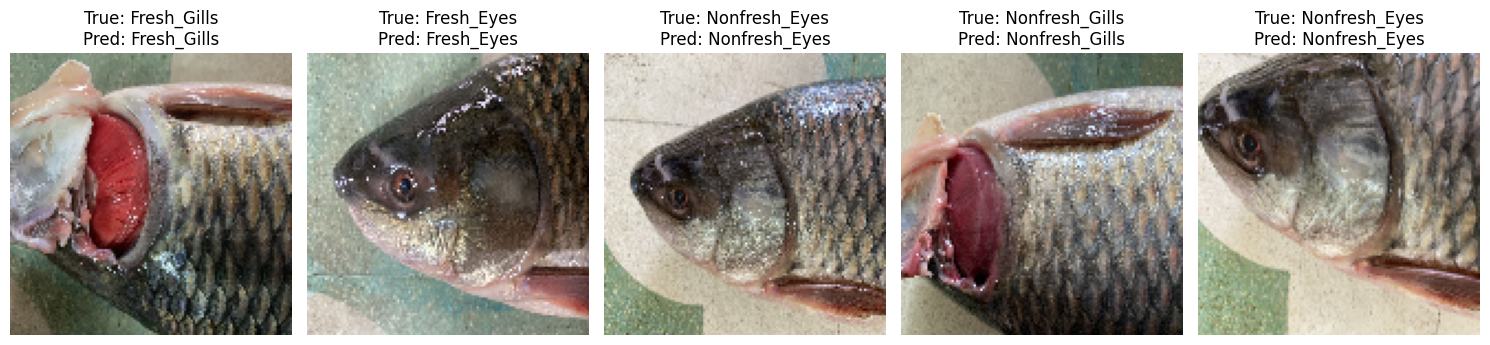


Predictions for selected random images:
Image 1: True Label: Fresh_Gills, Predicted Label: Fresh_Gills
Image 2: True Label: Fresh_Eyes, Predicted Label: Fresh_Eyes
Image 3: True Label: Nonfresh_Eyes, Predicted Label: Nonfresh_Eyes
Image 4: True Label: Nonfresh_Gills, Predicted Label: Nonfresh_Gills
Image 5: True Label: Nonfresh_Eyes, Predicted Label: Nonfresh_Eyes


In [52]:
# Call the function to predict random images
predict_random_images(test_generator, model, class_labels, num_images=5)

#### Model Deployment

In [53]:
# Model Deployment using Python Widgets
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import tensorflow.keras as tf_keras # Using your preferred import
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import io

# Define constants
IMG_SIZE = 512
classes = ['Fresh Eyes', 'Fresh Gills', 'Nonfresh Eyes', 'Nonfresh Gills']
model_path = 'fish_model.keras'

# Load the model
def load_model():
    print("Loading model...") # Debugging
    try:
        model = tf_keras.models.load_model(model_path, custom_objects={'data_augmentation': None})
        print("Model loaded successfully!")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

model = load_model()

# Image preprocessing function
def load_and_prep_image(image, img_shape=128, scale=True):
    """Loads an image, turns it into a tensor and reshapes it."""
    img = tf.image.resize(image, [img_shape, img_shape])
    return img / 255. if scale else img # Normalize pixel values

# Function to process uploaded image and make predictions
def predict_uploaded_image(change, output):
    with output:
        clear_output(wait=True)
        if model is None:
            print("Model failed to load. Please check the file path.")
            return
        
        uploaded_file = change['new']
        if not uploaded_file:
            print("No file uploaded. Please upload an image.")
            return
        
        try:
            # Read and process image
            file_content = uploaded_file[0].content
            image = Image.open(io.BytesIO(file_content)).convert("RGB")
            img_array = np.array(image)
            
            # Convert to tensor and preprocess
            img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
            img_tensor = load_and_prep_image(img_tensor, scale=False)
            img_array = tf.expand_dims(img_tensor, axis=0) # Add batch dimension
            
            # Predict
            pred_prob = model.predict(img_array)
            pred_class = classes[np.argmax(pred_prob)]
            
            # Display image
            plt.figure(figsize=(7, 7))
            plt.imshow(image) # Show the uploaded image
            plt.title(f"Predicted: {pred_class}, Prob: {np.max(pred_prob):.2f}", color="blue")
            plt.axis(False)
            plt.show()

        except Exception as e:
            print(f"Error during prediction: {e}")

Loading model...
Model loaded successfully!


In [ ]:
# File Upload Widget
upload = widgets.FileUpload(accept='image/*', multiple=False)
output = widgets.Output()
upload.observe(lambda change: predict_uploaded_image(change, output), names='value')

# Display UI
display(upload, output)

FileUpload(value=(), accept='image/*', description='Upload')

Output()

In [ ]:
# File Upload Widget
upload_1 = widgets.FileUpload(accept='image/*', multiple=False)
output_1 = widgets.Output()
upload_1.observe(lambda change: predict_uploaded_image(change, output_1), names='value')

# Display UI
display(upload_1, output_1)

FileUpload(value=(), accept='image/*', description='Upload')

Output()

In [ ]:
# File Upload Widget
upload_2 = widgets.FileUpload(accept='image/*', multiple=False)
output_2 = widgets.Output()
upload_2.observe(lambda change: predict_uploaded_image(change, output_2), names='value')

# Display UI
display(upload_2, output_2)

FileUpload(value=(), accept='image/*', description='Upload')

Output()

In [ ]:
# File Upload Widget
upload_3 = widgets.FileUpload(accept='image/*', multiple=False)
output_3 = widgets.Output()
upload_3.observe(lambda change: predict_uploaded_image(change, output_3), names='value')

# Display UI
display(upload_3, output_3)

FileUpload(value=(), accept='image/*', description='Upload')

Output()